In [1]:
# Business Problem 
# To develop a data-driven model that helps retail investors assess the risk-reward of IPO listing gains using publicly available IPO metrics.

In [2]:
# Business Question 
# Does a high institutional subscription ratio significantly increase the probability of positive listing day returns for retail investors?

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib. pyplot as plt 
import seaborn as sns 


In [4]:
df = pd.read_excel(r"C:\Users\kc\Documents\Initial Public Offerings.xlsx")

In [5]:
df

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.00,0.26,426.85,426.15,10.87
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.10,19.40,201.10,199.72,34.07
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.00,10.00,1294.05,61.76,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.00,50.81,1064.60,1062.70,57.72
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.00,-13.92,149.00,150.00,-5.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,2010-02-03,Infinite Computer Solutions Limited,189.80,48.44,106.02,11.08,43.22,165,178.35,8.09,473.75,473.75,187.12
557,2010-01-06,D B Corp Limited,384.22,68.52,26.17,3.42,39.54,212,250.00,17.92,274.75,273.00,29.60
558,2010-01-05,Godrej Properties Limited,468.85,7.45,0.41,0.38,4.00,490,510.00,4.08,1956.80,1952.10,299.35
559,2010-01-04,JSW Energy Limited,2700.00,2.88,0.15,0.40,1.68,100,102.00,2.00,536.30,536.40,436.30


In [6]:
# top 5 rows of the data 
df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,426.85,426.15,10.87
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,201.10,199.72,34.07
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,1294.05,61.76,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,1064.60,1062.70,57.72
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,149.00,150.00,-5.70


In [7]:
# bottom 5 rows of the data 
df.tail()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
556,2010-02-03,Infinite Computer Solutions Limited,189.80,48.44,106.02,11.08,43.22,165,178.35,8.09,473.75,473.75,187.12
557,2010-01-06,D B Corp Limited,384.22,68.52,26.17,3.42,39.54,212,250.00,17.92,274.75,273.00,29.60
558,2010-01-05,Godrej Properties Limited,468.85,7.45,0.41,0.38,4.00,490,510.00,4.08,1956.80,1952.10,299.35
559,2010-01-04,JSW Energy Limited,2700.00,2.88,0.15,0.40,1.68,100,102.00,2.00,536.30,536.40,436.30
560,2010-01-11,MBL Infrastructure Limited,102.60,3.35,2.65,0.40,1.97,180,190.00,5.56,40.75,40.78,-77.36


In [8]:
# to check all the information about the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                561 non-null    datetime64[ns]
 1   IPO_Name            561 non-null    object        
 2   Issue_Size(crores)  561 non-null    float64       
 3   QIB                 559 non-null    float64       
 4   HNI                 559 non-null    float64       
 5   RII                 559 non-null    float64       
 6   Total               559 non-null    float64       
 7   Offer Price         561 non-null    int64         
 8   List Price          561 non-null    float64       
 9   Listing Gain        561 non-null    float64       
 10  CMP(BSE)            559 non-null    float64       
 11  CMP(NSE)            551 non-null    float64       
 12  Current Gains       558 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1), objec

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,561,NaN,NaN,NaN,2019-02-28 23:00:57.754010880,2010-01-04 00:00:00,2015-05-26 00:00:00,2021-02-05 00:00:00,2023-11-07 00:00:00,2025-08-06 00:00:00,NaN
IPO_Name,561,560,Power Grid Corporation of India Ltd,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Size(crores),561.0,NaN,NaN,NaN,1411.483957,23.0,251.19,592.0,1237.51,27858.8,2642.439572
QIB,559.0,NaN,NaN,NaN,47.477013,0.0,2.35,13.72,76.255,331.6,63.325282
HNI,559.0,NaN,NaN,NaN,74.686834,0.0,1.71,13.2,81.11,958.07,136.785773
RII,559.0,NaN,NaN,NaN,15.972165,0.0,1.6,5.12,13.75,374.81,33.155961
Total,559.0,NaN,NaN,NaN,37.568891,0.11,2.245,11.52,55.07,326.49,53.804193
Offer Price,561.0,NaN,NaN,NaN,362.187166,10.0,126.0,258.0,493.0,2150.0,325.28259
List Price,561.0,NaN,NaN,NaN,430.38148,9.5,138.0,293.0,585.15,2725.0,416.667277
Listing Gain,561.0,NaN,NaN,NaN,18.029554,-31.73,-0.01,7.15,26.13,252.76,31.924815


In [10]:
# defined the function to check outliers 

def check_outliers_iqr(df, col):
    # Calculate quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Print results
    print(f"Column: {col}")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Outlier Count:", outliers.shape[0])
    print("-" * 40)

    return outliers

In [11]:
#   used the defined function for the specific column 
for col in ["Issue_Size(crores)", "QIB", "HNI",	"RII",	"Total", "Offer Price",	"List Price", "Listing Gain", "CMP(BSE)", "CMP(NSE)", "Current Gains"]:
 check_outliers_iqr(df, col)

Column: Issue_Size(crores)
Lower Bound: -1228.29
Upper Bound: 2716.99
Outlier Count: 74
----------------------------------------
Column: QIB
Lower Bound: -108.50750000000001
Upper Bound: 187.1125
Outlier Count: 28
----------------------------------------
Column: HNI
Lower Bound: -117.39000000000001
Upper Bound: 200.21
Outlier Count: 71
----------------------------------------
Column: RII
Lower Bound: -16.625
Upper Bound: 31.975
Outlier Count: 73
----------------------------------------
Column: Total
Lower Bound: -76.9925
Upper Bound: 134.3075
Outlier Count: 40
----------------------------------------
Column: Offer Price
Lower Bound: -424.5
Upper Bound: 1043.5
Outlier Count: 23
----------------------------------------
Column: List Price
Lower Bound: -532.7249999999999
Upper Bound: 1255.875
Outlier Count: 30
----------------------------------------
Column: Listing Gain
Lower Bound: -39.22
Upper Bound: 65.34
Outlier Count: 44
----------------------------------------
Column: CMP(BSE)
Lower

In [12]:
print(df.isnull().sum())

Date                   0
IPO_Name               0
Issue_Size(crores)     0
QIB                    2
HNI                    2
RII                    2
Total                  2
Offer Price            0
List Price             0
Listing Gain           0
CMP(BSE)               2
CMP(NSE)              10
Current Gains          3
dtype: int64


In [13]:
# Check Total Null Values in Each Column
print(df.isnull().sum())

Date                   0
IPO_Name               0
Issue_Size(crores)     0
QIB                    2
HNI                    2
RII                    2
Total                  2
Offer Price            0
List Price             0
Listing Gain           0
CMP(BSE)               2
CMP(NSE)              10
Current Gains          3
dtype: int64


In [14]:
# Drop missing values
df = df.dropna()

In [15]:
# Visualizations 

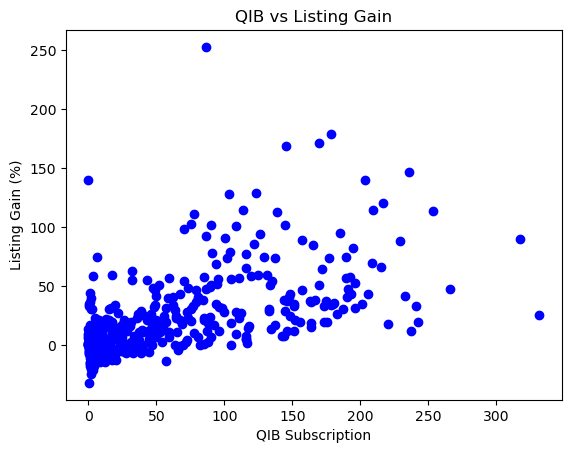

In [16]:
# QIB vs Listing Gain
plt.figure()
plt.scatter(df['QIB'], df['Listing Gain'], color='blue')
plt.xlabel("QIB Subscription")
plt.ylabel("Listing Gain (%)")
plt.title("QIB vs Listing Gain")
plt.show()

This plot shows the relationship between institutional subscription and listing returns.
It helps identify whether higher QIB subscription leads to better listing performance.

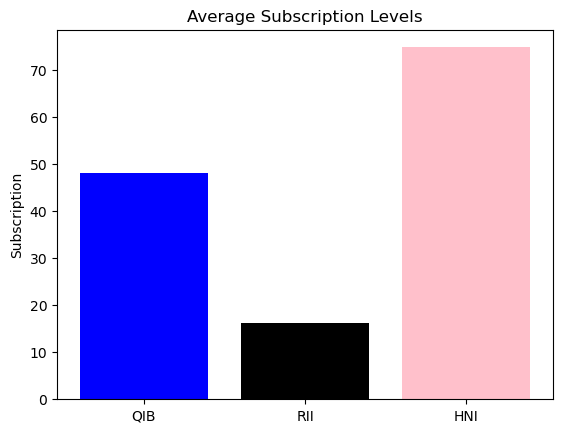

In [17]:
avg_sub = df[['QIB','RII','HNI']].mean()

plt.figure()
plt.bar(avg_sub.index, avg_sub.values, color=['blue','black','pink'])
plt.title("Average Subscription Levels")
plt.ylabel("Subscription")
plt.show()

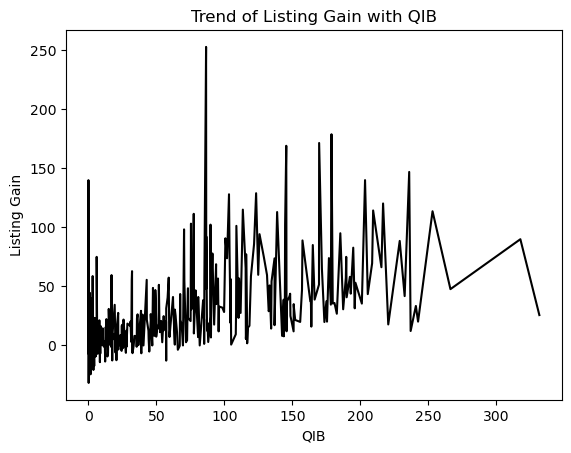

In [18]:
sorted_df = df.sort_values('QIB')

plt.figure()
plt.plot(sorted_df['QIB'], sorted_df['Listing Gain'], color='black')
plt.title("Trend of Listing Gain with QIB")
plt.xlabel("QIB")
plt.ylabel("Listing Gain")
plt.show()

This plot shows the trend of listing gains as QIB subscription increases.
It helps identify whether there is a consistent upward or inconsistent pattern.

C:\Users\kc\AppData\Local\Temp\ipykernel_11924\1566112291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['QIB_Category'] = pd.cut(df['QIB'], bins=[0,5,20,100], labels=['Low','Medium','High'])
C:\Users\kc\AppData\Local\Temp\ipykernel_11924\1566112291.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_gain = df.groupby('QIB_Category')['Listing Gain'].mean()


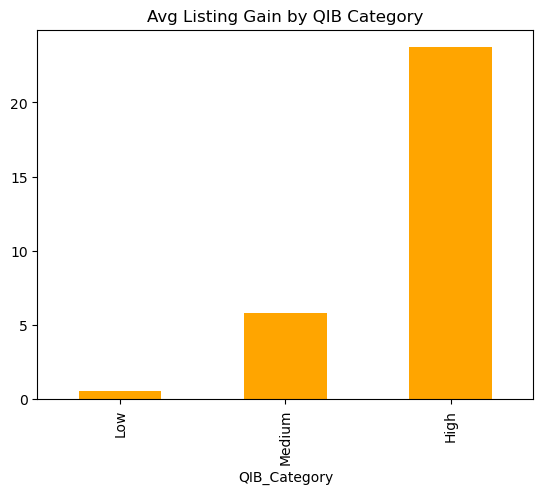

In [19]:
# Average Gain by QIB Category
df['QIB_Category'] = pd.cut(df['QIB'], bins=[0,5,20,100], labels=['Low','Medium','High'])
avg_gain = df.groupby('QIB_Category')['Listing Gain'].mean()

plt.figure()
avg_gain.plot(kind='bar', color='orange')
plt.title("Avg Listing Gain by QIB Category")
plt.show()

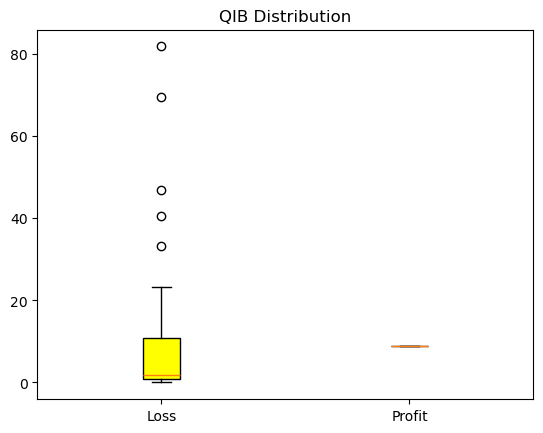

In [20]:
# QIB vs Gain/No Gain

plt.figure()
plt.boxplot([df[df['Listing Gain']==0]['QIB'],
             df[df['Listing Gain']==1]['QIB']],
            patch_artist=True,
            boxprops=dict(facecolor='yellow'))
plt.xticks([1,2], ['Loss','Profit'])
plt.title("QIB Distribution")
plt.show()

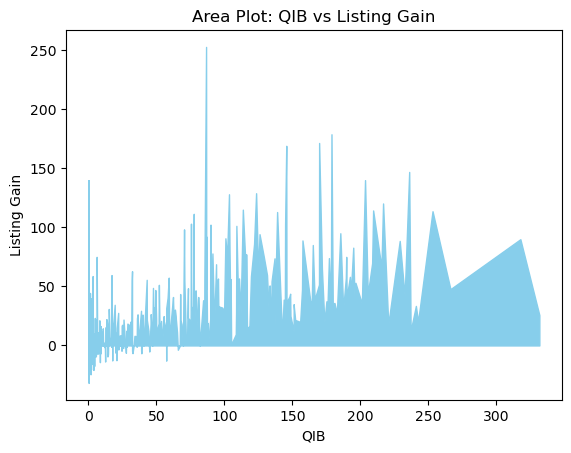

In [21]:
sorted_df = df.sort_values('QIB')

plt.figure()
plt.fill_between(sorted_df['QIB'], sorted_df['Listing Gain'], color='skyblue')
plt.title("Area Plot: QIB vs Listing Gain")
plt.xlabel("QIB")
plt.ylabel("Listing Gain")
plt.show()

In [37]:
# Remove rows where vital listing data is missing
df_clean = df.dropna(subset=['Listing Gain', 'QIB']).copy()
#  Answering the Business Question: Success Rate for High QIB (>50x)
qib_threshold = 50
high_qib_df = df_clean[df_clean['QIB'] > qib_threshold]
success_rate = (high_qib_df['Listing Gain'] > 0).mean() * 100
print(f"Success Rate for IPOs with QIB > 50x: {success_rate:.2f}%")

Success Rate for IPOs with QIB > 50x: 97.22%


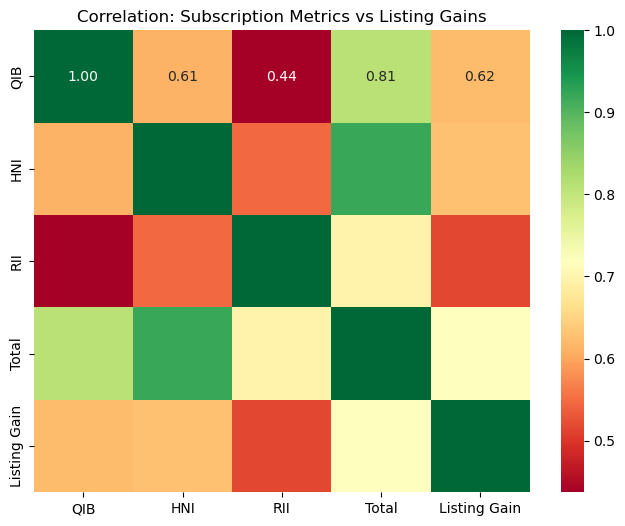

In [38]:
#  Correlation Heatmap
correlation_matrix = df_clean[['QIB', 'HNI', 'RII', 'Total', 'Listing Gain']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation: Subscription Metrics vs Listing Gains')
plt.show()




In [39]:
#  Defining the Risk-Reward Matrix
# We use the median QIB subscription as a benchmark for 'High' institutional interest
qib_median = df_clean['QIB'].median()

def categorize_ipo(row):
    if row['QIB'] >= qib_median and row['Listing Gain'] >= 0:
        return 'Safe Haven (High QIB, High Gain)'
    elif row['QIB'] >= qib_median and row['Listing Gain'] < 0:
        return 'The Trap (High QIB, Low Gain)'
    elif row['QIB'] < qib_median and row['Listing Gain'] >= 0:
        return 'Hidden Gems (Low QIB, High Gain)'
    else:
        return 'Avoid (Low QIB, Low Gain)'

df_clean['Category'] = df_clean.apply(categorize_ipo, axis=1)



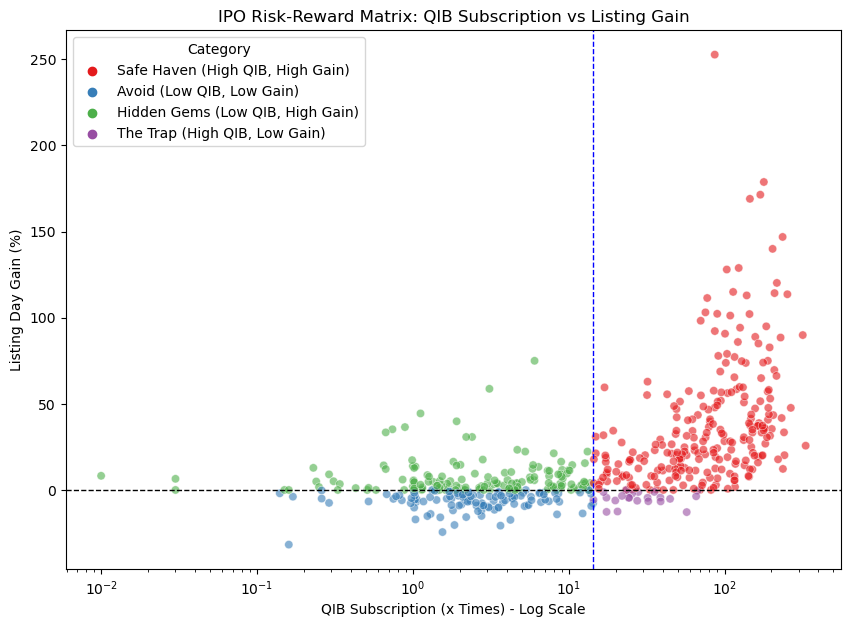

In [40]:
# 5. Visualizing the Matrix
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clean, x='QIB', y='Listing Gain', hue='Category', palette='Set1', alpha=0.6)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(qib_median, color='blue', linewidth=1, linestyle='--')
plt.xscale('log') # Log scale helps visualize highly skewed subscription numbers
plt.title('IPO Risk-Reward Matrix: QIB Subscription vs Listing Gain')
plt.ylabel('Listing Day Gain (%)')
plt.xlabel('QIB Subscription (x Times) - Log Scale')
plt.legend(title='Category')
plt.show()



In [41]:
# 6. Identifying "The Retail Trap"
# High Retail (>10x) but Low Institutional (<5x)
retail_trap = df_clean[(df_clean['RII'] > 10) & (df_clean['QIB'] < 5)]
trap_discount_prob = (retail_trap['Listing Gain'] < 0).mean() * 100
print(f"Probability of Listing Discount in 'Retail Traps': {trap_discount_prob:.2f}%")

Probability of Listing Discount in 'Retail Traps': 10.00%


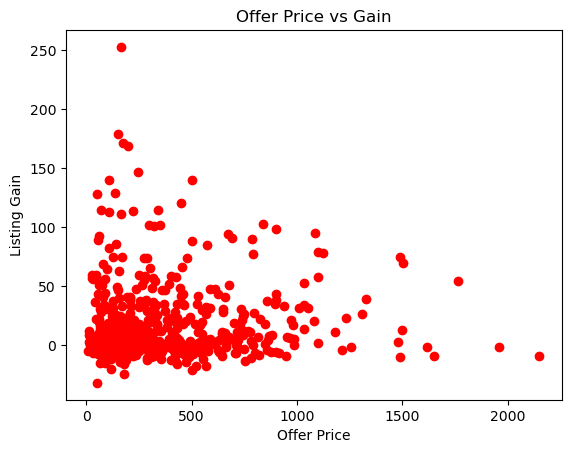

In [22]:
# Offer Price vs Listing Gain
plt.scatter(df['Offer Price'], df['Listing Gain'], color='red')
plt.xlabel("Offer Price")
plt.ylabel("Listing Gain")
plt.title("Offer Price vs Gain")
plt.show()

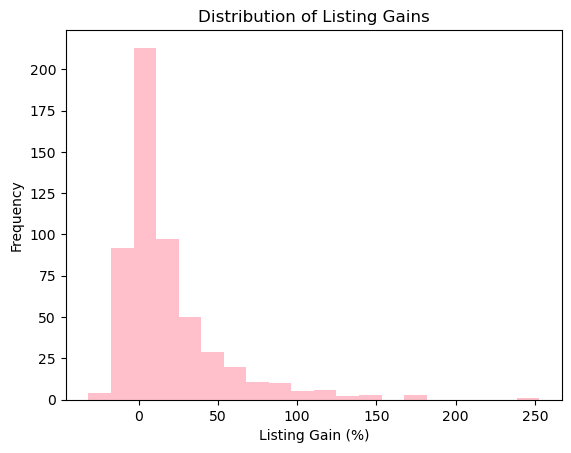

In [23]:
plt.figure()
plt.hist(df['Listing Gain'], bins=20, color = 'pink')
plt.title("Distribution of Listing Gains")
plt.xlabel("Listing Gain (%)")
plt.ylabel("Frequency")
plt.show()

This shows how listing gains are distributed across all IPOs.
It helps identify whether most IPOs are profitable or loss-making.

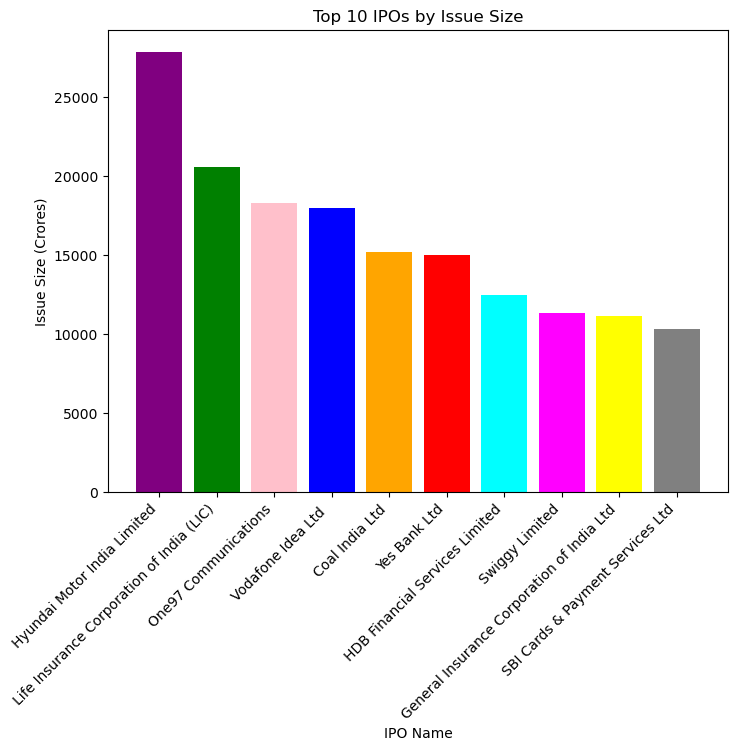

In [24]:
# top 10 IPO names with Issue size 

# Get top 10 IPOs by Issue Size
top_10 = df.sort_values(by='Issue_Size(crores)', ascending=False) \
           [['IPO_Name', 'Issue_Size(crores)']] \
           .head(10)


plt.figure(figsize=(8,6))
plt.bar(top_10["IPO_Name"], top_10["Issue_Size(crores)"], 
        color=["purple","green","pink","blue","orange",
               "red","cyan","magenta","yellow","grey"])

plt.title("Top 10 IPOs by Issue Size")
plt.xlabel("IPO Name")
plt.ylabel("Issue Size (Crores)")

# Rotate names so they don’t overlap
plt.xticks(rotation=45, ha='right')

plt.show()

This chart highlights the top IPOs based on issue size for comparison.
It helps understand whether large IPOs dominate the market.

In [25]:
df['QIB'] = pd.to_numeric(df['QIB'], errors='coerce')
df['Listing Gain'] = pd.to_numeric(df['Listing Gain'], errors='coerce')

df = df.dropna(subset=['QIB','Listing Gain'])


C:\Users\kc\AppData\Local\Temp\ipykernel_11924\4281469891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['QIB'] = pd.to_numeric(df['QIB'], errors='coerce')
C:\Users\kc\AppData\Local\Temp\ipykernel_11924\4281469891.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Listing Gain'] = pd.to_numeric(df['Listing Gain'], errors='coerce')


In [26]:
df['Gain_Flag'] = df['Listing Gain'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

df['QIB_Category'] = pd.cut(df['QIB'],
                           bins=[0,5,20,100],
                           labels=['Low','Medium','High'])

C:\Users\kc\AppData\Local\Temp\ipykernel_11924\1067617510.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = df.groupby('QIB_Category')['Gain_Flag'].value_counts(normalize=True).unstack()


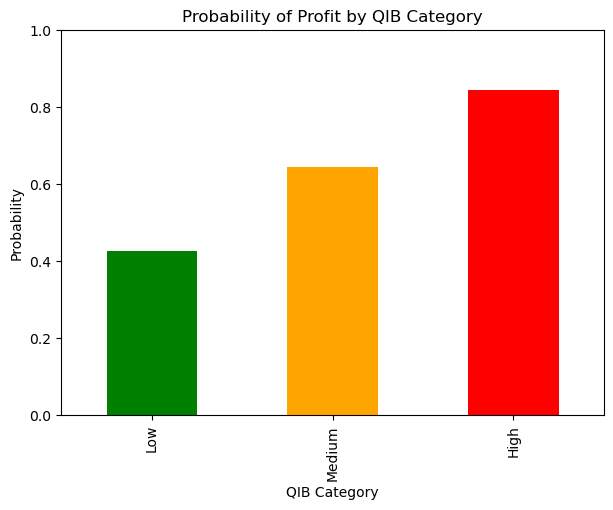

In [27]:
prob = df.groupby('QIB_Category')['Gain_Flag'].value_counts(normalize=True).unstack()

plt.figure(figsize=(7,5))
prob['Profit'].plot(kind='bar', color=['green','orange','red'])

plt.title("Probability of Profit by QIB Category")
plt.xlabel("QIB Category")
plt.ylabel("Probability")
plt.ylim(0,1)
plt.show()

This chart shows the likelihood of earning profit across different QIB levels.
It directly answers whether higher institutional subscription increases profit probability.

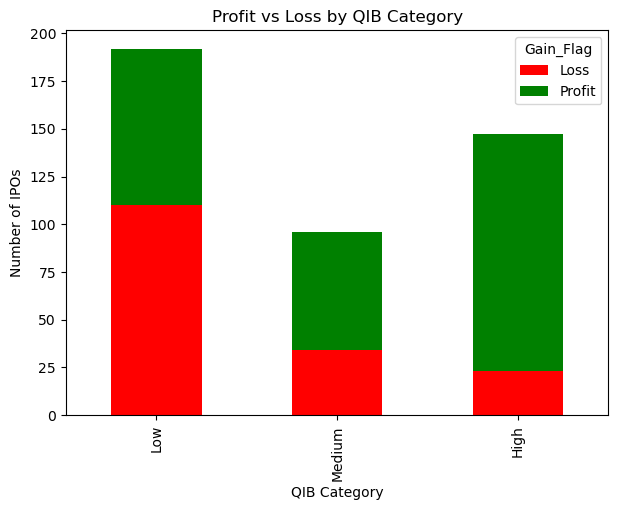

In [28]:
# Profit vs Loss Distribution

pivot = pd.crosstab(df['QIB_Category'], df['Gain_Flag'])

pivot.plot(kind='bar', stacked=True, color=['red','green'], figsize=(7,5))

plt.title("Profit vs Loss by QIB Category")
plt.xlabel("QIB Category")
plt.ylabel("Number of IPOs")
plt.show()

This chart compares the number of profitable and loss-making IPOs across QIB categories.
It helps visualize both risk and return in different subscription levels.

In [29]:
numeric_df = df.select_dtypes(include=['number'])

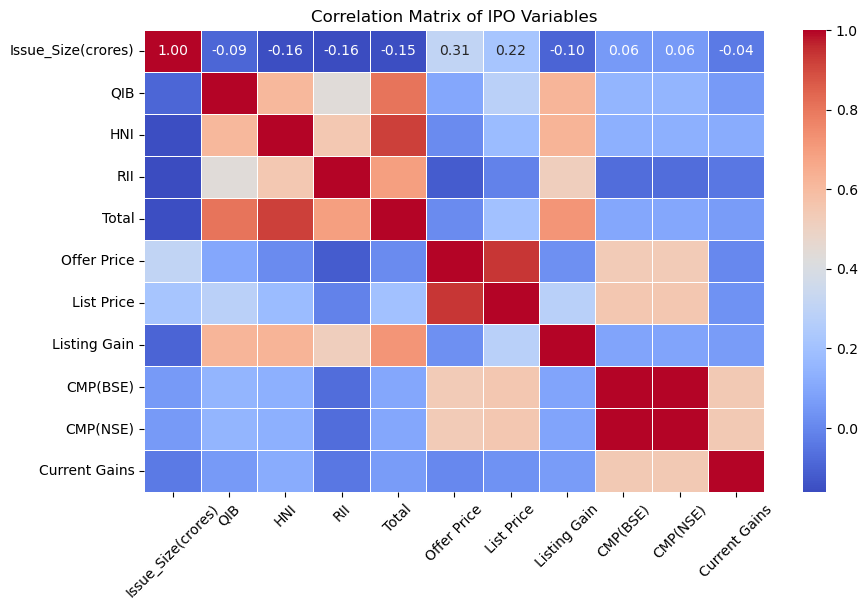

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",          # show 2 decimal values
            linewidths=0.5)

plt.title("Correlation Matrix of IPO Variables")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

This visualization shows the relationship between numerical variables like QIB, RII, and listing gain. It helps identify which factors are most strongly related to IPO performance.

In [31]:
# Predicting listing gain 

In [32]:
from sklearn.model_selection import train_test_split

# Step 1: Select Features (inputs)
X = df[['QIB', 'HNI', 'RII', 'Total', 'Issue_Size(crores)']]

# Step 2: Target Variable (output)
y = df['Listing Gain']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [34]:
y_pred = model.predict(X_test)

In [35]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

     Actual  Predicted
318   -7.67    -1.9701
78    41.78    70.8139
362    0.69    35.4584
91    31.45    55.2563
507   -0.89    -1.4860
210   -8.62    -4.1752
177   16.43     8.2545
250   56.67    73.6790
531   -7.41    -4.1804
500    7.69    12.2832
